# Real-data comparisons: $\Delta\chi^2$ vs TSNR2 vs EW(H$\alpha$)

Remakes of the DESI_completeness_model slide plots (pp. 28, 35, 37) with the
released DR1 dwarf catalog + Iron BGS Bright catalog.

**Message:** redshift confidence ($\Delta\chi^2$) correlates strongly with
spectral type (EW(H$\alpha$)) at fixed fiber mag, while TSNR2 -- the
observing-conditions metric used for LSS redshift-failure weights -- carries
no information about type. A TSNR2-based weight is therefore type-blind and
cannot correct a quenched fraction.

Data: `/global/cfs/cdirs/desi/users/virajvm/desi_dwarf_cats/iron/desi_dr1_dwarf_catalog.fits`
(MAIN + TRACTOR + FASTSPEC HDUs, row-matched) and
`/pscratch/sd/v/virajvm/catalog/Iron_bgs_bright_all_phot_final_filter.fits`
(TSNR2_BGS; crossmatched to the dwarfs by TARGETID).

Figures are written to `~/DESI2_LOWZ/quenched_fracs_nbs/incompleteness_plots/`
(never into the repo).

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from astropy.io import fits
from astropy.table import Table

sys.path.insert(0, os.path.abspath('../..'))   # code/ for plot_style
from plot_style import (apply_paper_style, make_subplots, reshape_axes,
                        MARGIN_LABEL, MARGIN_TICKS, MARGIN_PAD,
                        MARGIN_SHARED, MARGIN_SPLIT, MARGIN_CBAR)
apply_paper_style()

OUT_DIR = os.path.expanduser('~/DESI2_LOWZ/quenched_fracs_nbs/incompleteness_plots')
DWARF_CAT = '/global/cfs/cdirs/desi/users/virajvm/desi_dwarf_cats/iron/desi_dr1_dwarf_catalog.fits'
BGS_CAT = '/pscratch/sd/v/virajvm/catalog/Iron_bgs_bright_all_phot_final_filter.fits'

In [2]:
# ---- DR1 dwarf catalog: MAIN + TRACTOR (fibermag) + FASTSPEC (EW), row-matched
with fits.open(DWARF_CAT) as f:
    main = f['MAIN'].data
    dw = {
        'TARGETID': np.asarray(main['TARGETID']),
        'Z': np.asarray(main['Z'], dtype=float),
        'DELTACHI2': np.asarray(main['DELTACHI2'], dtype=float),
        'IS_BGS_BRIGHT': np.asarray(main['IS_BGS_BRIGHT'], dtype=bool),
        'RFIB': np.asarray(f['TRACTOR'].data['FIBERMAG_R'], dtype=float),
        'HALPHA_EW': np.asarray(f['FASTSPEC'].data['HALPHA_EW'], dtype=float),
        'HALPHA_EW_IVAR': np.asarray(f['FASTSPEC'].data['HALPHA_EW_IVAR'], dtype=float),
    }
print(f"dwarf catalog: {len(dw['TARGETID'])} rows, "
      f"BGS Bright: {dw['IS_BGS_BRIGHT'].sum()}")

# ---- Iron BGS Bright catalog: TSNR2_BGS source
bgs = Table.read(BGS_CAT)
bgs_tid = np.asarray(bgs['TARGETID'])
print(f"BGS catalog: {len(bgs)} rows")

# crossmatch TSNR2_BGS onto the dwarfs by TARGETID
order = np.argsort(bgs_tid)
pos = np.searchsorted(bgs_tid[order], dw['TARGETID'])
pos = np.clip(pos, 0, len(order) - 1)
hit = bgs_tid[order][pos] == dw['TARGETID']
dw['TSNR2_BGS'] = np.where(hit, np.asarray(bgs['TSNR2_BGS'])[order][pos], np.nan)
print(f"dwarfs with TSNR2_BGS: {hit.sum()} ({100*hit.mean():.0f}%)")

dwarf catalog: 469703 rows, BGS Bright: 181822


BGS catalog: 4413825 rows


dwarfs with TSNR2_BGS: 165442 (35%)


## Fig A -- EW(H$\alpha$) vs $\Delta\chi^2$ at fixed fiber mag (slide-28 remake)
$\Delta\chi^2$ tracks line strength tightly: at fixed depth and brightness, the
redshift-confidence axis *is* (mostly) a spectral-type axis.

saved realdata_ew_vs_dchi2


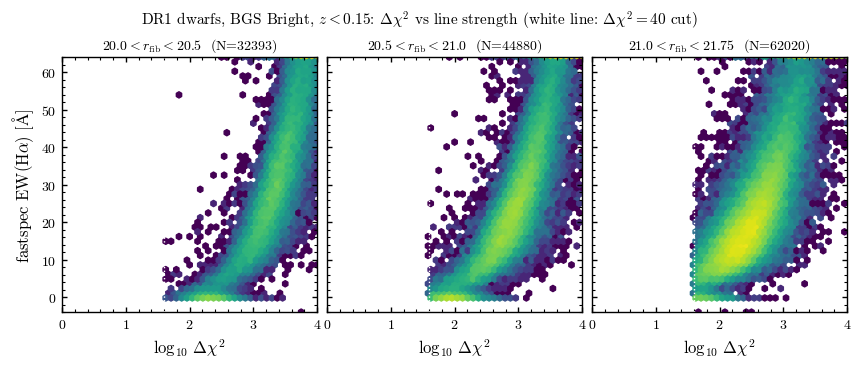

In [3]:
slices = [(20.0, 20.5), (20.5, 21.0), (21.0, 21.75)]
base = (dw['IS_BGS_BRIGHT'] & (dw['Z'] > 0.001) & (dw['Z'] < 0.15)
        & np.isfinite(dw['HALPHA_EW']) & (dw['DELTACHI2'] > 0)
        & (dw['HALPHA_EW_IVAR'] > 0))

fig, flat = make_subplots(ncol=3, nrow=1, plot_size=2.55,
                          col_spacing=[MARGIN_LABEL, MARGIN_SHARED, MARGIN_SHARED, MARGIN_PAD],
                          row_spacing=[MARGIN_LABEL, 0.5], return_fig=True)
for ax, (lo, hi) in zip(flat, slices):
    m = base & (dw['RFIB'] > lo) & (dw['RFIB'] < hi)
    ax.hexbin(np.log10(dw['DELTACHI2'][m].clip(1e-2)),
              dw['HALPHA_EW'][m].clip(-4, 64), gridsize=48,
              extent=[0, 4, -4, 64], cmap='viridis', norm=LogNorm(), mincnt=1,
              rasterized=True)
    ax.axvline(np.log10(40), color='w', ls=':', lw=1)
    ax.set_title(f'${lo} < r_{{\\rm fib}} < {hi}$  (N={m.sum()})', fontsize=10)
    ax.set_xlabel(r'$\log_{10}\,\Delta\chi^2$')
    ax.set_xlim(0, 4); ax.set_ylim(-4, 64)
flat[0].set_ylabel(r'fastspec EW(H$\alpha$) [$\mathrm{\AA}$]')
for ax in flat[1:]:
    ax.set_yticklabels([])
fig.text(0.5, 0.955, r'DR1 dwarfs, BGS Bright, $z<0.15$: $\Delta\chi^2$ vs line strength'
         r' (white line: $\Delta\chi^2=40$ cut)', ha='center', fontsize=11)
for ext in ('png', 'pdf'):
    fig.savefig(f'{OUT_DIR}/realdata_ew_vs_dchi2.{ext}', dpi=250, bbox_inches='tight')
print('saved realdata_ew_vs_dchi2')

## Fig B -- TSNR2 vs $\Delta\chi^2$ (slide-35 remake)
Left: full Iron BGS Bright at $z<0.15$ in a fiber-mag slice -- broad, weak
correlation. Middle/right: dwarfs additionally conditioned on EW -- at fixed
type + brightness, TSNR2 adds little of what $\Delta\chi^2$ knows.

saved realdata_tsnr2_vs_dchi2


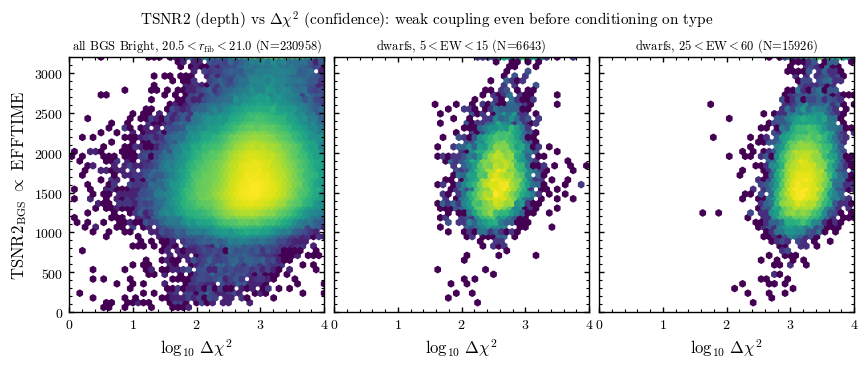

In [4]:
rf_lo, rf_hi = 20.5, 21.0
bgs_z = np.asarray(bgs['Z'], dtype=float)
bgs_rf = np.asarray(bgs['FIBERMAG_R'], dtype=float)
bgs_d2 = np.asarray(bgs['DELTACHI2'], dtype=float)
bgs_ts = np.asarray(bgs['TSNR2_BGS'], dtype=float)
mb = ((bgs_z > 0.001) & (bgs_z < 0.15) & (bgs_rf > rf_lo) & (bgs_rf < rf_hi)
      & (bgs_d2 > 0) & np.isfinite(bgs_ts))

md_all = (base & (dw['RFIB'] > rf_lo) & (dw['RFIB'] < rf_hi)
          & np.isfinite(dw['TSNR2_BGS']))
ew_cuts = [(5, 15), (25, 60)]

fig, flat = make_subplots(ncol=3, nrow=1, plot_size=2.55,
                          col_spacing=[MARGIN_LABEL, MARGIN_SHARED, MARGIN_SHARED, MARGIN_PAD],
                          row_spacing=[MARGIN_LABEL, 0.5], return_fig=True)
panels = [(mb, bgs_d2, bgs_ts, f'all BGS Bright, ${rf_lo}<r_{{\\rm fib}}<{rf_hi}$'),
          (md_all & (dw['HALPHA_EW'] > ew_cuts[0][0]) & (dw['HALPHA_EW'] < ew_cuts[0][1]),
           dw['DELTACHI2'], dw['TSNR2_BGS'], f'dwarfs, ${ew_cuts[0][0]}<$EW$<{ew_cuts[0][1]}$'),
          (md_all & (dw['HALPHA_EW'] > ew_cuts[1][0]) & (dw['HALPHA_EW'] < ew_cuts[1][1]),
           dw['DELTACHI2'], dw['TSNR2_BGS'], f'dwarfs, ${ew_cuts[1][0]}<$EW$<{ew_cuts[1][1]}$')]
for ax, (m, d2, ts, title) in zip(flat, panels):
    ax.hexbin(np.log10(d2[m].clip(1e-2)), ts[m].clip(0, 3200), gridsize=48,
              extent=[0, 4, 0, 3200], cmap='viridis', norm=LogNorm(), mincnt=1,
              rasterized=True)
    ax.set_title(f'{title} (N={m.sum()})', fontsize=9)
    ax.set_xlabel(r'$\log_{10}\,\Delta\chi^2$')
    ax.set_xlim(0, 4); ax.set_ylim(0, 3200)
flat[0].set_ylabel(r'TSNR2$_{\rm BGS}$ $\propto$ EFFTIME')
for ax in flat[1:]:
    ax.set_yticklabels([])
fig.text(0.5, 0.955, r'TSNR2 (depth) vs $\Delta\chi^2$ (confidence): weak coupling'
         r' even before conditioning on type', ha='center', fontsize=11)
for ext in ('png', 'pdf'):
    fig.savefig(f'{OUT_DIR}/realdata_tsnr2_vs_dchi2.{ext}', dpi=250, bbox_inches='tight')
print('saved realdata_tsnr2_vs_dchi2')

## Fig C -- TSNR2 vs EW(H$\alpha$) at fixed fiber mag (appendix-A remake)
The depth metric is (by design) independent of spectral type: TSNR2 cannot
distinguish a quenched dwarf from a star-forming one, while their redshift
success rates differ enormously.

saved realdata_tsnr2_vs_ew


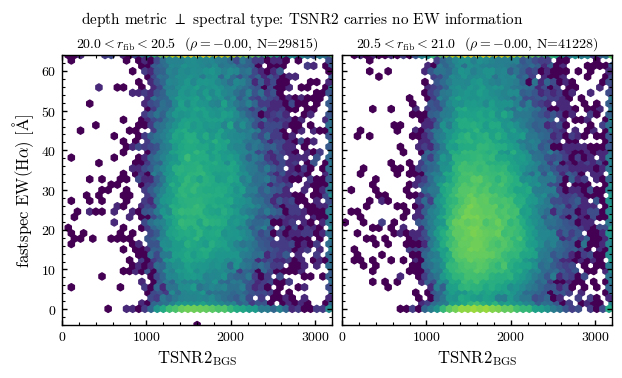

In [5]:
fig, flat = make_subplots(ncol=2, nrow=1, plot_size=2.7,
                          col_spacing=[MARGIN_LABEL, MARGIN_SHARED, MARGIN_PAD],
                          row_spacing=[MARGIN_LABEL, 0.5], return_fig=True)
for ax, (lo, hi) in zip(flat, [(20.0, 20.5), (20.5, 21.0)]):
    m = (base & (dw['RFIB'] > lo) & (dw['RFIB'] < hi) & np.isfinite(dw['TSNR2_BGS']))
    ax.hexbin(dw['TSNR2_BGS'][m].clip(0, 3200), dw['HALPHA_EW'][m].clip(-4, 64),
              gridsize=44, extent=[0, 3200, -4, 64], cmap='viridis',
              norm=LogNorm(), mincnt=1, rasterized=True)
    rho = np.corrcoef(dw['TSNR2_BGS'][m], dw['HALPHA_EW'][m].clip(-4, 200))[0, 1]
    ax.set_title(f'${lo} < r_{{\\rm fib}} < {hi}$  ($\\rho={rho:.2f}$, N={m.sum()})',
                 fontsize=10)
    ax.set_xlabel(r'TSNR2$_{\rm BGS}$')
    ax.set_xlim(0, 3200); ax.set_ylim(-4, 64)
flat[0].set_ylabel(r'fastspec EW(H$\alpha$) [$\mathrm{\AA}$]')
flat[1].set_yticklabels([])
fig.text(0.5, 0.955, r'depth metric $\perp$ spectral type: TSNR2 carries no EW information',
         ha='center', fontsize=11)
for ext in ('png', 'pdf'):
    fig.savefig(f'{OUT_DIR}/realdata_tsnr2_vs_ew.{ext}', dpi=250, bbox_inches='tight')
print('saved realdata_tsnr2_vs_ew')

### Interpretation (for the talk)
- **Fig A:** at fixed fiber mag, $\Delta\chi^2$ is largely a *type* axis -- the
  $\Delta\chi^2>40$ cut is implicitly a cut on line strength, i.e. on star formation.
- **Fig B:** TSNR2 and $\Delta\chi^2$ decouple once brightness/type are fixed;
  the LSS success-rate variable and the actual confidence variable are not interchangeable
  for dwarfs.
- **Fig C:** TSNR2 is type-blind by construction -- a TSNR2-based failure weight
  averages over quenched and star-forming galaxies and therefore cannot correct
  a quenched fraction. Type-aware purity/completeness weights (this project) can.